In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import re
import warnings
warnings.filterwarnings('ignore')

articles = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-2/articles_features.parquet')
customer_features = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-2/customer_features.parquet')
transactions = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-1/transactions_clean.parquet')

print(f"Articles: {articles.shape}")
print(f"Customer features: {customer_features.shape}")
print(articles['detail_desc'].head(5))

Articles: (81940, 28)
Customer features: (99345, 18)
0              Jersey top with narrow shoulder straps.
1              Jersey top with narrow shoulder straps.
2              Jersey top with narrow shoulder straps.
3    Microfibre T-shirt bra with underwired, moulde...
4    Microfibre T-shirt bra with underwired, moulde...
Name: detail_desc, dtype: object


In [3]:
def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'unknown product'
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

articles['clean_desc'] = articles['detail_desc'].apply(clean_text)

# Also combine product_type_name and product_group_name into the text
# This helps TF-IDF because descriptions alone sometimes miss the garment type
articles['combined_text'] = (
    articles['product_group_name'].fillna('').str.lower() + ' ' +
    articles['product_type_name'].fillna('').str.lower() + ' ' +
    articles['clean_desc']
)

print("Sample cleaned text:")
print(articles['combined_text'].iloc[0])
print()
print(articles['combined_text'].iloc[1])

Sample cleaned text:
garment upper body vest top jersey top with narrow shoulder straps

garment upper body vest top jersey top with narrow shoulder straps


In [4]:
tfidf = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 most informative words
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.85,            # Ignore words that appear in more than 85% of docs (too common)
    ngram_range=(1, 2),     # Use single words AND two-word phrases
    stop_words='english'    # Remove common English words like 'the', 'and', 'is'
)

tfidf_matrix = tfidf.fit_transform(articles['combined_text'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Rows = articles, Columns = vocabulary terms")

TF-IDF matrix shape: (81940, 5000)
Rows = articles, Columns = vocabulary terms


In [5]:
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

# Normalize so all vectors have unit length - important for clustering text
tfidf_normalized = normalize(tfidf_reduced)

print(f"Reduced matrix shape: {tfidf_normalized.shape}")
print(f"Explained variance ratio (first 10 components): {svd.explained_variance_ratio_[:10].round(3)}")

Reduced matrix shape: (81940, 50)
Explained variance ratio (first 10 components): [0.01  0.022 0.017 0.015 0.012 0.011 0.01  0.01  0.009 0.008]


K=4 | Silhouette: 0.0959 | Inertia: 61133
K=5 | Silhouette: 0.1345 | Inertia: 58723
K=6 | Silhouette: 0.1435 | Inertia: 55573
K=7 | Silhouette: 0.1382 | Inertia: 54489
K=8 | Silhouette: 0.1588 | Inertia: 51998
K=9 | Silhouette: 0.1562 | Inertia: 50945
K=10 | Silhouette: 0.1855 | Inertia: 48169
K=11 | Silhouette: 0.1718 | Inertia: 47598
K=12 | Silhouette: 0.1891 | Inertia: 45351


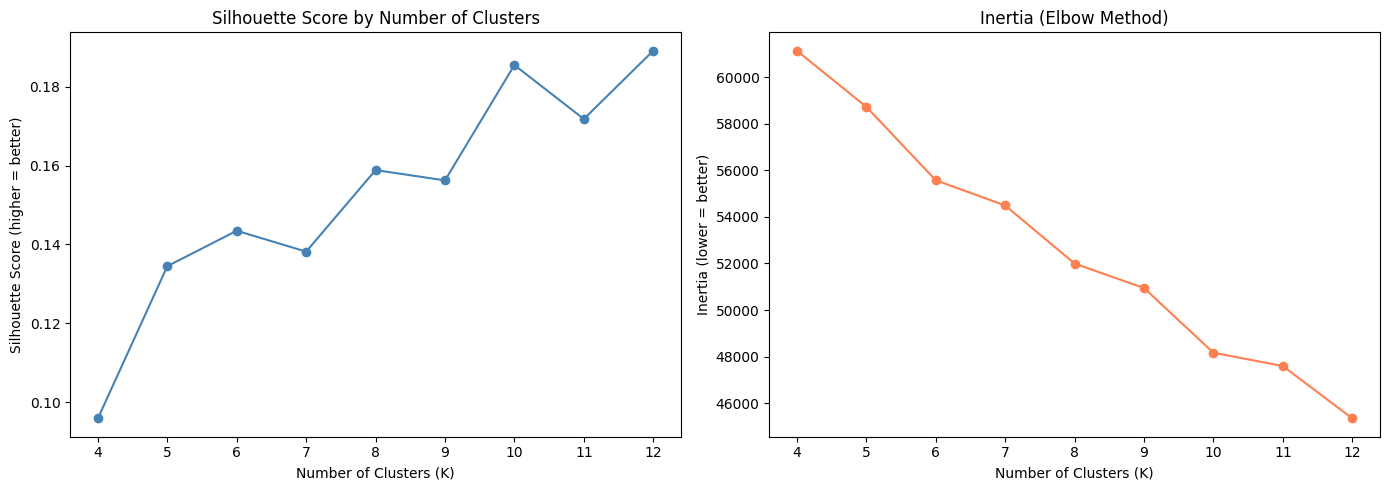


Best K by silhouette score: 12


In [6]:
silhouette_scores = {}
inertia_scores = {}

K_range = range(4, 13)  # Test 4 to 12 clusters

for k in K_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
    labels = kmeans.fit_predict(tfidf_normalized)
    
    # Silhouette score - higher is better, max is 1.0
    sil = silhouette_score(tfidf_normalized, labels, sample_size=5000, random_state=42)
    silhouette_scores[k] = sil
    inertia_scores[k] = kmeans.inertia_
    
    print(f"K={k} | Silhouette: {sil:.4f} | Inertia: {kmeans.inertia_:.0f}")

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 'o-', color='steelblue')
axes[0].set_title('Silhouette Score by Number of Clusters')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score (higher = better)')

axes[1].plot(list(inertia_scores.keys()), list(inertia_scores.values()), 'o-', color='coral')
axes[1].set_title('Inertia (Elbow Method)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Inertia (lower = better)')

plt.tight_layout()
plt.savefig('/kaggle/working/cluster_selection.png', dpi=150)
plt.show()

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest K by silhouette score: {best_k}")

In [7]:
# Use the best K you found above - adjust this number based on your output
FINAL_K = best_k

kmeans_final = MiniBatchKMeans(n_clusters=FINAL_K, random_state=42, batch_size=1000, n_init=10)
articles['style_cluster'] = kmeans_final.fit_predict(tfidf_normalized)

print(f"Cluster distribution:")
print(articles['style_cluster'].value_counts().sort_index())

Cluster distribution:
style_cluster
0      4095
1      2252
2      8926
3      4616
4      4719
5      4341
6     16170
7      8590
8      3692
9      6215
10     9935
11     8389
Name: count, dtype: int64


In [8]:
# For each cluster, show the top TF-IDF terms and most common product types
feature_names = tfidf.get_feature_names_out()
cluster_centers = svd.inverse_transform(kmeans_final.cluster_centers_)

print("TOP TERMS AND PRODUCT TYPES PER CLUSTER")
print("=" * 60)

for cluster_id in range(FINAL_K):
    # Top terms from TF-IDF centroid
    top_term_indices = cluster_centers[cluster_id].argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_term_indices]
    
    # Most common product types in this cluster
    cluster_articles = articles[articles['style_cluster'] == cluster_id]
    top_types = cluster_articles['product_type_name'].value_counts().head(5)
    top_groups = cluster_articles['product_group_name'].value_counts().head(3)
    
    print(f"\nCLUSTER {cluster_id} ({len(cluster_articles)} articles)")
    print(f"Top terms: {', '.join(top_terms)}")
    print(f"Top product types: {top_types.index.tolist()}")
    print(f"Top product groups: {top_groups.index.tolist()}")

TOP TERMS AND PRODUCT TYPES PER CLUSTER

CLUSTER 0 (4095 articles)
Top terms: sweatshirt, sweatshirt fabric, ribbing, cuffs hem, fabric, brushed inside, brushed, inside, soft brushed, cuffs
Top product types: ['Sweater', 'Hoodie', 'Top', 'Garment Set', 'Jumpsuit/Playsuit']
Top product groups: ['Garment Upper body', 'Garment Full body', 'Underwear']

CLUSTER 1 (2252 articles)
Top terms: skirt, body skirt, lower, lower body, garment lower, skirt short, high, waist, high waist, length skirt
Top product types: ['Skirt', 'Trousers', 'Garment Set', 'Shorts', 'Sarong']
Top product groups: ['Garment Lower body', 'Garment Full body', 'Swimwear']

CLUSTER 2 (8926 articles)
Top terms: dress, body dress, garment body, seam, short, dress short, seam waist, neck, sleeves, garment
Top product types: ['Dress', 'Jumpsuit/Playsuit', 'Garment Set', 'Dungarees', 'Costumes']
Top product groups: ['Garment Full body', 'Garment Upper body', 'Swimwear']

CLUSTER 3 (4616 articles)
Top terms: swimwear, bra, biki

In [9]:
cluster_labels = {
    0: 'Sweatshirts & Hoodies',          # sweatshirt, ribbing, brushed
    1: 'Skirts & Lower Body Wear',       # skirt, high waist
    2: 'Dresses & Full Body Wear',       # dress, jumpsuit
    3: 'Swimwear & Lingerie',            # bikini, bra
    4: 'Jackets & Outerwear',            # jacket, coat
    5: 'Denim & Bottoms',                # denim, jeans
    6: 'Basic Tops & Innerwear',         # t-shirt, cotton, socks
    7: 'Blouses & Fashion Tops',         # blouse, vest
    8: 'Footwear',                       # shoes, boots
    9: 'Knitwear & Sweaters',            # jumper, knit
    10: 'Trousers & Bottom Wear',        # trousers, leggings
    11: 'Accessories & Bags'             # bags, earrings
}

articles['style_group'] = articles['style_cluster'].map(cluster_labels)

print(articles['style_group'].value_counts())

style_group
Basic Tops & Innerwear      16170
Trousers & Bottom Wear       9935
Dresses & Full Body Wear     8926
Blouses & Fashion Tops       8590
Accessories & Bags           8389
Knitwear & Sweaters          6215
Jackets & Outerwear          4719
Swimwear & Lingerie          4616
Denim & Bottoms              4341
Sweatshirts & Hoodies        4095
Footwear                     3692
Skirts & Lower Body Wear     2252
Name: count, dtype: int64


In [10]:
# Join transactions with article style groups
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

trans_style = transactions.merge(
    articles[['article_id', 'style_cluster', 'style_group']], 
    on='article_id', 
    how='left'
)

# Most purchased style group per customer
customer_style = (
    trans_style.groupby(['customer_id', 'style_group'])
    .size()
    .reset_index(name='style_count')
    .sort_values('style_count', ascending=False)
    .drop_duplicates(subset='customer_id')
    .rename(columns={'style_group': 'style_affinity'})[['customer_id', 'style_affinity', 'style_count']]
)

# Also get style diversity - how many different style groups does this customer buy from
style_diversity = (
    trans_style.groupby('customer_id')['style_group']
    .nunique()
    .reset_index()
    .rename(columns={'style_group': 'style_diversity'})
)

customer_style = customer_style.merge(style_diversity, on='customer_id', how='left')

print(f"Customer style affinity shape: {customer_style.shape}")
print(customer_style['style_affinity'].value_counts())

Customer style affinity shape: (99345, 4)
style_affinity
Basic Tops & Innerwear      20344
Swimwear & Lingerie         16457
Blouses & Fashion Tops      12203
Trousers & Bottom Wear      12201
Dresses & Full Body Wear     9997
Denim & Bottoms              7881
Knitwear & Sweaters          7464
Accessories & Bags           3438
Jackets & Outerwear          3426
Sweatshirts & Hoodies        2839
Skirts & Lower Body Wear     1628
Footwear                     1467
Name: count, dtype: int64


In [11]:
customer_features = customer_features.merge(customer_style, on='customer_id', how='left')

print(f"Updated customer features shape: {customer_features.shape}")
print(customer_features.columns.tolist())
print(customer_features[['customer_id', 'RFM_score', 'style_affinity', 'style_diversity']].head(10))

Updated customer features shape: (99345, 21)
['customer_id', 'last_purchase_date', 'frequency', 'monetary', 'recency', 'avg_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'top_category', 'top_product_type', 'avg_price_paid', 'price_band', 'top_season', 'age_group', 'club_member_status', 'fashion_news_frequency', 'style_affinity', 'style_count', 'style_diversity']
                                         customer_id  RFM_score  \
0  0000ffa57a8098a6cd99c0f0782b3e674f47d68db69dc1...          4   
1  00018385675844f7a6babbed41b5655b5727fb16483b6e...          8   
2  0002e4924f38a599994d83110e5db96d62bbffce7fea85...          3   
3  00036ffb474cd9818bd0d9045fd5863b0167aabae75e61...         11   
4  000383021a8cf9a542b9c855b42f99aa76374873661e83...          5   
5  0003c98542d16e740156638a7d133d93360d3ff3d0b7ec...          4   
6  000538c14c490fee547e2703439f70bdb8748e2a62f875...         12   
7  000563485cbb7850b0a93c6606f89c5b961c6647d1bd48...         11   
8  0006d1fc72f8126

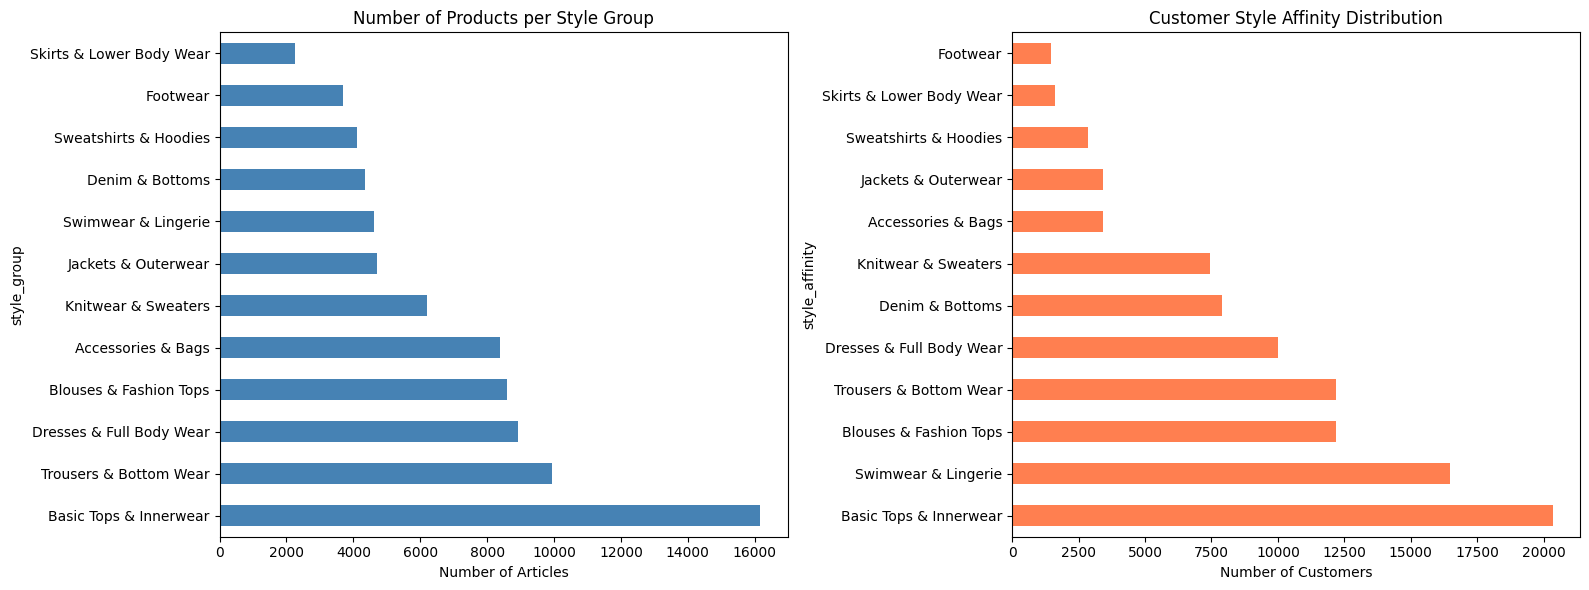

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Style group sizes
articles['style_group'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Products per Style Group')
axes[0].set_xlabel('Number of Articles')

# Customer style affinity distribution
customer_features['style_affinity'].value_counts().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Customer Style Affinity Distribution')
axes[1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.savefig('/kaggle/working/style_groups.png', dpi=150)
plt.show()

In [13]:
customer_features.to_parquet('/kaggle/working/customer_features_with_style.parquet', index=False)
articles.to_parquet('/kaggle/working/articles_with_style.parquet', index=False)

print("Saved customer_features_with_style.parquet")
print(f"Shape: {customer_features.shape}")
print("\nSaved articles_with_style.parquet")
print(f"Shape: {articles.shape}")

# Final null check on style affinity
print(f"\nNull style affinity count: {customer_features['style_affinity'].isnull().sum()}")

Saved customer_features_with_style.parquet
Shape: (99345, 21)

Saved articles_with_style.parquet
Shape: (81940, 32)

Null style affinity count: 0
